# Training Script for ML Time Series Models


## Settings and Imports


In [9]:
#!/usr/bin/env python3
import os
import joblib
import pandas as pd
import numpy as np

from utils.data_preparation import prepare_data_for_modeling
from utils.visualize_model_performance import evaluate_and_plot_model_sklearn

# Set to True if you want to retrain the model (e.g. after changing features or target)
RETRAIN = True
# Set to True if you want to reprocess the data (e.g. after changing features or target)
REPROCESS_DATA = True

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# This features describe today's weather and load. We predict next-day load.
FEATURES_TODAY = ['Temp', 'Min Temp', 'Max Temp', 'Wind Speed',
                  'Sunshine Duration', 'Cloud Cover', 'Cooling Degrees', 'Heating Degrees', 'load', 'load_lag_1',
                  'load_lag_7', 'load_lag_14', 'rolling_mean_7', 'rolling_mean_14', 'std_7', 'std_14']

# Temporal features
FEATURES_TIME = ['is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

# Remove weak features based on feature-importance + SHAP analysis
LOW_IMPORTANCE_FEATURES = ['Cooling Degrees', 'Sunshine Duration', 'Cloud Cover', 'Heating Degrees', 'Wind Speed', 'std_7', 'std_14']
REDUCED_FEATURES = [feature for feature in FEATURES_TODAY if feature not in LOW_IMPORTANCE_FEATURES]

FEATURES = REDUCED_FEATURES + FEATURES_TIME

# We will predict the load of the next day
TARGET = "load_t+1"

# No need to scale binary features and already encoded cyclic features
SCALE_FEATURES = REDUCED_FEATURES

print(f"Using {len(FEATURES)} features for retraining: {FEATURES}")

Using 14 features for retraining: ['Temp', 'Min Temp', 'Max Temp', 'load', 'load_lag_1', 'load_lag_7', 'load_lag_14', 'rolling_mean_7', 'rolling_mean_14', 'is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## Dataset Loading and Preparation


In [10]:
data_dict, _ = prepare_data_for_modeling(FEATURES, TARGET, SCALE_FEATURES, save_scaler=True, save_data=True, reprocess_data = REPROCESS_DATA)

# Training Data
X_train_scaled = data_dict['X_train_scaled']
X_train = data_dict['X_train']
y_train = data_dict['y_train']

# Validation Data
X_val_scaled = data_dict['X_val_scaled']
X_val = data_dict['X_val']
y_val = data_dict['y_val']

# Test Data
X_test_scaled = data_dict['X_test_scaled']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

# Keep feature names on scaled matrices to avoid sklearn warnings
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=FEATURES, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURES, index=X_test.index)

test_df = data_dict['test_df'].copy()  # Keep non-feature columns such as timestamps

# Inspection
X_test_scaled_df.describe()

,Temp,Min Temp,Max Temp,load,load_lag_1,load_lag_7,load_lag_14,rolling_mean_7,rolling_mean_14,is_holiday,dow_sin,dow_cos,month_sin,month_cos
count,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,3.480000e+02,3.480000e+02
mean,0.007158,0.003937,0.019236,-0.414438,-0.409866,-0.397435,-0.405769,-0.604603,-0.620335,0.022989,-0.002247,-0.004665,-2.575891e-02,-4.594937e-02
std,0.948287,0.962785,0.938562,0.959999,0.964175,0.971590,0.963542,1.018002,1.040264,0.150083,0.708912,0.707318,7.162565e-01,6.979081e-01
min,-1.986051,-2.282169,-1.886332,-2.399262,-2.400242,-2.402551,-2.400349,-1.978810,-1.935329,0.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00
25%,-0.708266,-0.812644,-0.702130,-0.973492,-0.974313,-0.959582,-0.958811,-1.496985,-1.565793,0.000000,-0.781831,-0.900969,-8.660254e-01,-8.660254e-01
50%,-0.006448,0.015875,-0.019157,-0.450431,-0.447731,-0.434164,-0.444314,-0.900497,-0.945006,0.000000,0.000000,-0.222521,-2.449294e-16,-1.836970e-16
75%,0.772468,0.852374,0.742252,0.277516,0.298673,0.334915,0.270760,0.175810,0.229412,0.000000,0.781831,0.623490,8.660254e-01,5.000000e-01
max,2.145492,1.909634,2.368378,1.703235,1.702713,1.695320,1.693459,1.313314,1.232045,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00


## Training


### 1.) Random Forest Regressor


Test MAE: 1013.71
Test RMSE: 1343.12


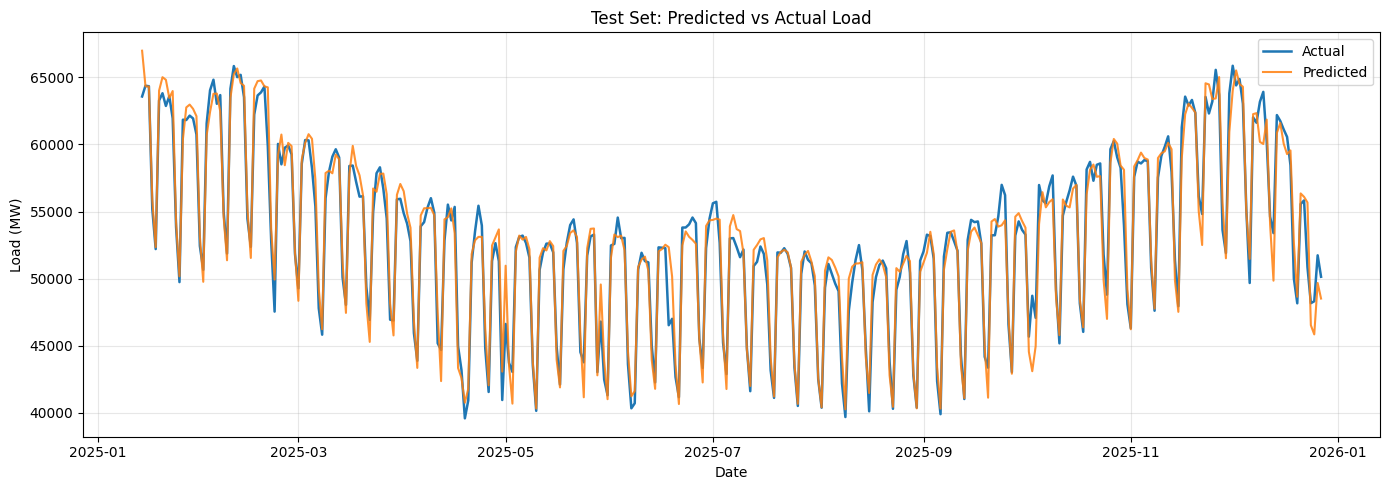

In [11]:
if not os.path.exists("models/rf_load_forecaster.joblib") or RETRAIN:
    from sklearn.ensemble import RandomForestRegressor

    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_regressor.fit(X_train_scaled_df, y_train)

    # evaluate_and_plot_model(rf_regressor, X_val_scaled_df, y_val, val_df)
    evaluate_and_plot_model_sklearn(rf_regressor, X_test_scaled_df, y_test, test_df)

    joblib.dump(rf_regressor, "models/rf_load_forecaster.joblib")

### 2.) XGBoost Regressor


[0]	validation_0-rmse:6684.10924
[1]	validation_0-rmse:6511.63519
[2]	validation_0-rmse:6341.68068
[3]	validation_0-rmse:6183.71748
[4]	validation_0-rmse:6026.72854
[5]	validation_0-rmse:5880.98144
[6]	validation_0-rmse:5730.20891
[7]	validation_0-rmse:5602.17149
[8]	validation_0-rmse:5458.68314
[9]	validation_0-rmse:5321.39611
[10]	validation_0-rmse:5189.21596
[11]	validation_0-rmse:5059.48284
[12]	validation_0-rmse:4937.15641
[13]	validation_0-rmse:4817.57394
[14]	validation_0-rmse:4702.06514
[15]	validation_0-rmse:4588.23677
[16]	validation_0-rmse:4480.48369
[17]	validation_0-rmse:4375.63639
[18]	validation_0-rmse:4269.46815
[19]	validation_0-rmse:4173.75049
[20]	validation_0-rmse:4070.90123
[21]	validation_0-rmse:3972.09520
[22]	validation_0-rmse:3886.32413
[23]	validation_0-rmse:3802.39508
[24]	validation_0-rmse:3713.86367
[25]	validation_0-rmse:3628.37587
[26]	validation_0-rmse:3546.37559
[27]	validation_0-rmse:3466.11157
[28]	validation_0-rmse:3388.66558
[29]	validation_0-rmse:3

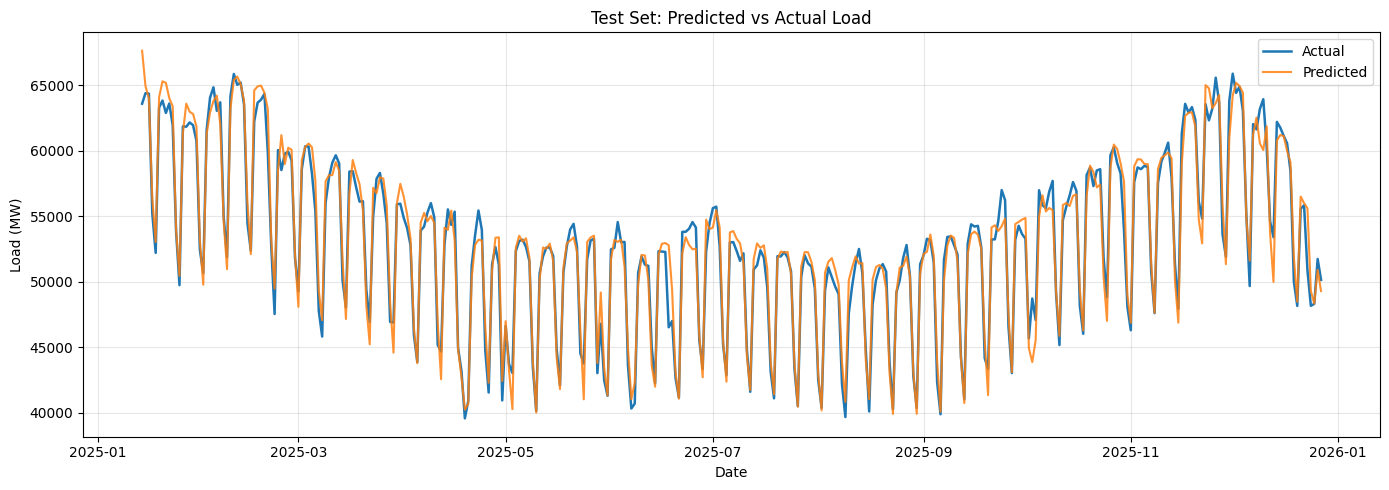

In [12]:
if not os.path.exists("models/xgb_load_forecaster.joblib") or RETRAIN:
    from xgboost import XGBRegressor

    xgb_regressor = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        early_stopping_rounds=100
    )
    xgb_regressor.fit(X_train_scaled_df, y_train, eval_set=[(X_val_scaled_df, y_val)])

    # evaluate_and_plot_model(xgb_regressor, X_val_scaled_df, y_val, val_df)
    evaluate_and_plot_model_sklearn(xgb_regressor, X_test_scaled_df, y_test, test_df)

    joblib.dump(xgb_regressor, "models/xgb_load_forecaster.joblib")

## Feature Importance

### Permutation Invariance

/opt/homebrew/Cellar/python@3.11/3.11.14_3/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.11/3.11.14_3/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


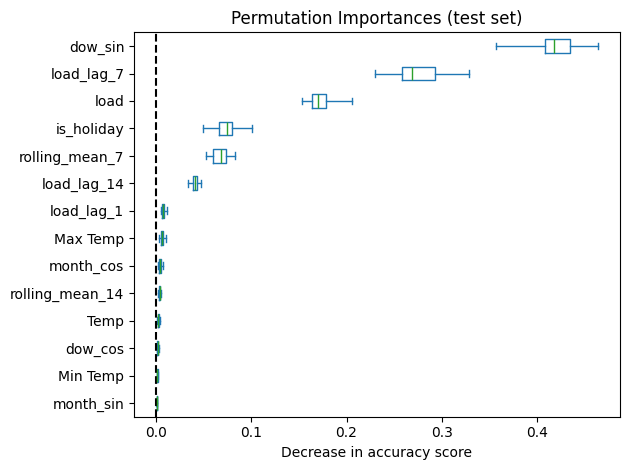

In [13]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    rf_regressor,
    X_test_scaled_df,
    y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=2,
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test_scaled_df.columns[sorted_importances_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

### Feature Importance XGBoost

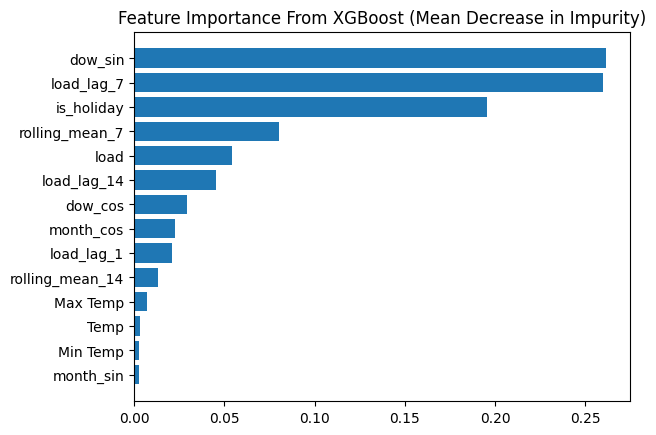

In [14]:
import matplotlib.pyplot as plt

importances = xgb_regressor.feature_importances_

plt.barh(X_train.columns[np.argsort(importances)], importances[np.argsort(importances)])
plt.title("Feature Importance From XGBoost (Mean Decrease in Impurity)")
plt.show()

### SHAP

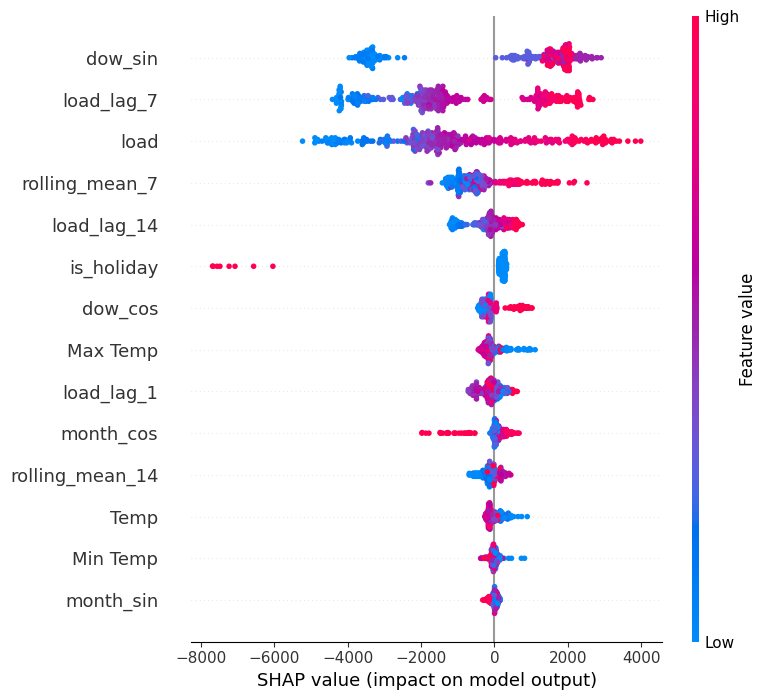

In [15]:
import shap
explainer = shap.Explainer(xgb_regressor)
shap_values = explainer(X_test_scaled_df)
shap.summary_plot(shap_values, X_test_scaled_df)

In [16]:
# As a result of the feature importance analysis, it is evident that the following features do not contribute significantly to the model's predictive performance 
# and can be removed without negatively impacting the model's accuracy:
# - Cooling Degrees 
# - Sunshine Duration
# - Cloud Cover
# - Heating Degrees 
# - Wind Speed
# - Standard deviation features of the load (std_7, std_14) 